Plot the recall rate as a function of binned LPP amplitude for different categories.


In [1]:
import os

from jaxcmr.analyses.cat_recall_by_lpp import plot_cat_recall_by_lpp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
data_name = "TalmiEEG"
data_query =  "data['subject'] > 0"
category_field = "condition"
contrast_name = "condition"
category_values = [1, 2]
labels = ["Negative", "Neutral"]
lpp_field = "EarlyLPP"
color_cycle = ["red", "black"]
ylim = [0, .8]
output_path = "projects/TalmiEEG/cat_lpp_spc_EarlyLPP.png"

In [3]:
# Parameters
data_name = "TalmiEEG"
data_query = "data['subject'] > 0"
category_field = "condition"
category_values = [1, 2]
labels = ["Negative", "Neutral"]
color_cycle = ["red", "black"]
ylim = [0, 1.0]
output_path = "projects/TalmiEEG/results/figures/cat_recall_by_lpp_EarlyLPP.png"
lpp_field = "EarlyLPP"


In [4]:
project_root = find_project_root()
data_path = os.path.join(project_root, "data", f"{data_name}.h5")
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)

# data["EarlyLPP"] = data["EarlyLPP"] + jnp.abs(jnp.min(data["EarlyLPP"]))
# data["LateLPP"] = data["LateLPP"] + jnp.abs(jnp.min(data["LateLPP"]))

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


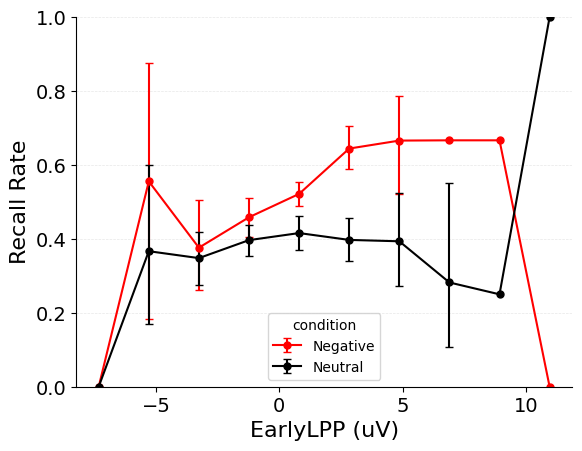

In [5]:
axis = plot_cat_recall_by_lpp(
    datasets=[data],
    trial_masks=trial_mask,
    category_field=category_field,
    category_values=category_values,
    lpp_field=lpp_field,
    contrast_name=contrast_name,
    labels=labels,
    color_cycle=color_cycle
)
axis.set_ylim(ylim)
plt.savefig(output_path, bbox_inches="tight", dpi=600)


[-7.3182697 -5.28781   -3.25735   -1.2268898  0.8035703  2.8340304
  4.8644905  6.894951   8.92541   10.95587  ]


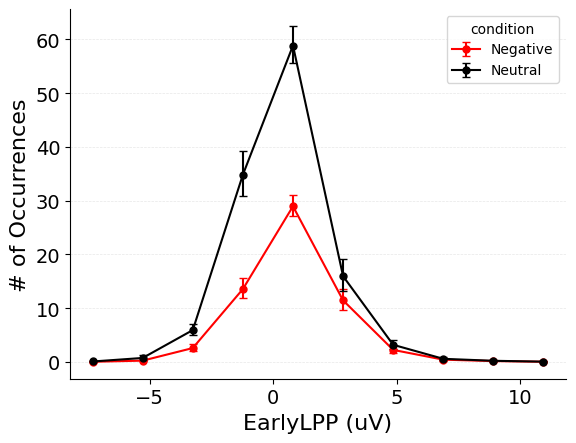

In [6]:
"""Category-filtered LPP-binned recall analyses."""

from __future__ import annotations

from typing import Optional, Sequence

import jax.numpy as jnp
from jax import jit, vmap
from jax.nn import one_hot
from matplotlib import rcParams  # type: ignore
from matplotlib.axes import Axes

from jaxcmr.helpers import apply_by_subject
from jaxcmr.plotting import init_plot, plot_data, set_plot_labels
from jaxcmr.typing import Array, Bool, Float, Integer, RecallDataset

def category_recall_counts(
    recalls: Integer[Array, " recall_events"],
    categories: Integer[Array, " study_positions"],
    category_value: int,
    list_length: int,
) -> Float[Array, " study_positions"]:
    """Returns recall counts per position restricted to a category."""
    position_counts = jnp.bincount(recalls, length=list_length + 1)[1:]
    return position_counts * (categories == category_value)


def category_lpp_recall_histogram(
    recalls: Integer[Array, " trial_count recall_positions"],
    lpp: Float[Array, " trial_count study_positions"],
    categories: Integer[Array, " trial_count study_positions"],
    category_value: int,
    bin_edges: Float[Array, " bin_count_plus_one"],
    list_length: int,
) -> Float[Array, " bin_count"]:
    """Returns category-filtered recall rate as a function of LPP bins.

    Args:
      recalls: Trial by recall position array of recalled items. 1-indexed; 0 for no recall.
      lpp: Trial by study position array of LPP values.
      categories: Trial by study position array of item categories.
      category_value: Category value to compute recall rates over.
      bin_edges: LPP bin edges used for aggregation.
      list_length: Length of the study list.
    """
    thresholds = bin_edges[1:-1]
    num_bins = bin_edges.shape[0] - 1
    bin_indices = jnp.digitize(lpp, thresholds)
    bin_one_hot = one_hot(bin_indices, num_bins, dtype=lpp.dtype)
    matches = (categories == category_value).astype(lpp.dtype)

    recall_counts = vmap(
        category_recall_counts,
        in_axes=(0, 0, None, None),
    )(recalls, categories, category_value, list_length)

    exposure_counts = (matches[..., None] * bin_one_hot).sum(axis=(0, 1))
    recall_bin_counts = (recall_counts[..., None] * bin_one_hot).sum(axis=(0, 1))
    exposure_counts = exposure_counts.astype(lpp.dtype)
    return exposure_counts
    # return jnp.where(exposure_counts > 0, recall_bin_counts / exposure_counts, 0.0)


def cat_lpp_spc(
    dataset: RecallDataset,
    category_field: str,
    category_value: int,
    lpp_field: str = "LateLPP",
    bin_edges: Optional[Float[Array, " bin_count_plus_one"]] = None,
    bin_count: int = 10,
) -> Float[Array, " bin_count"]:
    """Returns category-filtered recall rate as a function of LPP bins.

    Args:
      dataset: Recall dataset containing per-item LPP metadata.
      category_field: Key in ``dataset`` providing item categories per study position.
      category_value: Category value to compute the recall curve over.
      lpp_field: Key in ``dataset`` providing LPP values per study position.
      bin_edges: LPP bin edges used for aggregation. Computed from the dataset if ``None``.
      bin_count: Number of LPP bins when ``bin_edges`` is not provided.
    """
    recalls = dataset["recalls"]
    lpp = dataset[lpp_field]
    categories = dataset[category_field]
    list_length = categories.shape[1]

    if bin_edges is None:
        lpp_min = jnp.min(lpp)
        lpp_max = jnp.max(lpp)
        bin_edges = jnp.linspace(lpp_min, lpp_max, bin_count + 1)

    return category_lpp_recall_histogram(
        recalls, lpp, categories, category_value, bin_edges, list_length
    )


def plot_cat_lpp_spc(
    datasets: Sequence[RecallDataset] | RecallDataset,
    trial_masks: Sequence[Bool[Array, " trial_count"]] | Bool[Array, " trial_count"],
    category_field: str,
    category_values: Sequence[int],
    lpp_field: str = "LateLPP",
    bin_edges: Optional[Float[Array, " bin_count_plus_one"]] = None,
    bin_count: int = 10,
    color_cycle: Optional[list[str]] = None,
    labels: Optional[Sequence[str]] = None,
    contrast_name: Optional[str] = None,
    axis: Optional[Axes] = None,
) -> Axes:
    """Returns Matplotlib ``Axes`` with category-filtered LPP-binned recall curves.

    Args:
      datasets: Datasets containing trial data to be plotted.
      trial_masks: Masks selecting trials in each dataset.
      category_field: Keys providing item categories per study position.
      category_values: Category values to compute the recall curves over.
      lpp_field: Key in ``dataset`` providing LPP values per study position.
      bin_edges: LPP bin edges used for aggregation. Computed from the datasets if ``None``.
      bin_count: Number of bins when ``bin_edges`` is not provided.
      color_cycle: Colors for plotting each dataset.
      labels: Labels per dataset or category. Assumed per-category if multiple values provided.
      contrast_name: Legend title for contrasts.
      axis: Existing Matplotlib ``Axes`` to plot on.
    """
    axis = init_plot(axis)

    if color_cycle is None:
        color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]

    if labels is None:
        size = len(category_values) if len(category_values) > 1 else len(datasets)
        labels = [""] * size

    if isinstance(datasets, dict):
        datasets = [datasets]

    if isinstance(trial_masks, jnp.ndarray):
        trial_masks = [trial_masks] * len(datasets)

    if bin_edges is None:
        bin_edges = _compute_lpp_bins(
            datasets, lpp_field, trial_masks, bin_count
        )
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    color_index = 0
    for data_index, data in enumerate(datasets):
        for label_index, category_value in enumerate(category_values):
            subject_values = jnp.vstack(
                apply_by_subject(
                    data,
                    trial_masks[data_index],
                    jit(
                        cat_lpp_spc,
                        static_argnames=(
                            "category_field",
                            "category_value",
                            "lpp_field",
                            "bin_count",
                        ),
                    ),
                    category_field=category_field,
                    category_value=category_value,
                    lpp_field=lpp_field,
                    bin_edges=bin_edges,
                    bin_count=bin_count,
                )
            )

            color = color_cycle[color_index % len(color_cycle)]
            color_index += 1
            plot_data(
                axis,
                bin_centers,
                subject_values,
                labels[label_index] if len(category_values) > 1 else labels[data_index],
                color,
            )

    set_plot_labels(axis, f"{lpp_field} (uV)", "Recall Rate", contrast_name)
    # axis.set_xticks(jnp.array(bin_centers))
    print(bin_centers)

    return axis


def _compute_lpp_bins(datasets, lpp_field, trial_masks, bin_count):
    minima = []
    maxima = []
    for data_index, data in enumerate(datasets):
        masked_lpp = data[lpp_field][trial_masks[data_index]]
        minima.append(jnp.min(masked_lpp))
        maxima.append(jnp.max(masked_lpp))
    global_min = jnp.min(jnp.stack(minima))
    global_max = jnp.max(jnp.stack(maxima))
    return jnp.linspace(global_min, global_max, bin_count + 1)


no_condition_data = data.copy()
# no_condition_data['condition'] = jnp.ones_like(data['condition'])

# color_cycle=["#1f77b4"]

axis = plot_cat_lpp_spc(
    datasets=[no_condition_data],
    trial_masks=trial_mask,
    category_field=category_field,
    category_values=category_values,
    lpp_field=lpp_field,
    color_cycle=color_cycle,
    contrast_name=category_field,
    labels=labels
)
axis.set_ylabel("# of Occurrences")
plt.savefig(output_path.replace('.png', '_counts.png'), bbox_inches="tight", dpi=600)
# axis.set_ylim(0, .8)

In [7]:
# no_condition_data = data.copy()
# no_condition_data['condition'] = jnp.ones_like(data['condition'])

# color_cycle=["#1f77b4"]

# axis = plot_cat_lpp_spc(
#     datasets=[no_condition_data],
#     trial_masks=trial_mask,
#     category_field=category_field,
#     category_values=[1],
#     lpp_field="EarlyLPP",
#     color_cycle=color_cycle,
#     # contrast_name=category_field,
#     # labels=["Negative", "Neutral"],
# )
# axis.set_ylim(0, .8)
# plt.savefig("projects/TalmiEEG/no_condition_cat_lpp_spc_early.png", bbox_inches="tight", dpi=600)

In [8]:
# no_condition_data = data.copy()
# no_condition_data['subject'] = jnp.ones_like(data['subject'])
# no_condition_data['condition'] = data['subject'] * jnp.ones_like(data['condition'])

# color_cycle=["#1f77b4"]

# axis = plot_cat_lpp_spc(
#     datasets=[no_condition_data],
#     trial_masks=trial_mask,
#     category_field=category_field,
#     category_values=jnp.unique(data['subject']).tolist(),
#     lpp_field="EarlyLPP",
#     color_cycle=color_cycle,
#     # contrast_name=category_field,
#     # labels=["Negative", "Neutral"],
# )
# plt.savefig("projects/TalmiEEG/no_condition_subjects_cat_lpp_spc_early.png", bbox_inches="tight", dpi=600)
# # axis.set_ylim(0, .8)